[*********************100%***********************]  1 of 1 completed


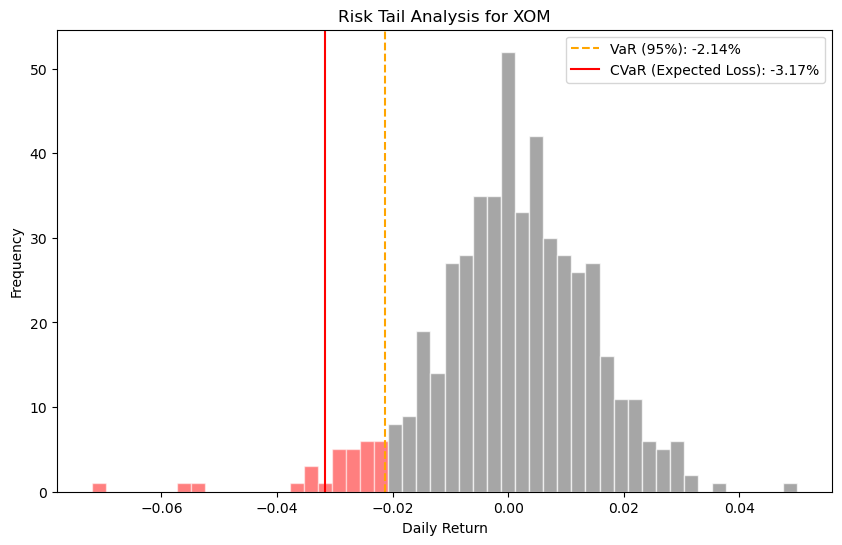

XOM VaR: -2.14%
XOM CVaR: -3.17%


In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_deep_risk(ticker, confidence_level=0.95):
    # 1. Download data
    data = yf.download(ticker, period="2y")['Close']
    if isinstance(data, pd.DataFrame):
        data = data[ticker]
    
    returns = data.pct_change().dropna()
    
    # 2. Calculate VaR (The Threshold)
    var_percentile = (1 - confidence_level) * 100
    var_value = np.percentile(returns, var_percentile)
    
    # 3. Calculate CVaR / Expected Shortfall (The Average of the 'Tail')
    # We take all returns that are worse than the VaR and average them
    tail_losses = returns[returns <= var_value]
    cvar_value = tail_losses.mean()
    
    # 4. Visualization
    plt.figure(figsize=(10, 6))
    n, bins, patches = plt.hist(returns, bins=50, alpha=0.7, color='gray', edgecolor='white')
    
    # Color the 'Tail' red to show the danger zone
    for i in range(len(bins)-1):
        if bins[i] < var_value:
            patches[i].set_facecolor('red')
            patches[i].set_alpha(0.5)

    # Lines for VaR and CVaR
    plt.axvline(var_value, color='orange', linestyle='--', label=f'VaR (95%): {var_value:.2%}')
    plt.axvline(cvar_value, color='red', linestyle='-', label=f'CVaR (Expected Loss): {cvar_value:.2%}')
    
    plt.title(f"Risk Tail Analysis for {ticker}")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
    return var_value, cvar_value

# Test it on ExxonMobil
var, cvar = calculate_deep_risk("XOM")
print(f"XOM VaR: {var:.2%}")
print(f"XOM CVaR: {cvar:.2%}")